# Part 4 - Exercise 2

POS tagging exercise with a bidirectional LSTM.


## Basic setup

In [1]:
import os
import random
import urllib.request
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)

Running on: cpu


## Read the UD English EWT data

The dataset is already split into train, development, and test files.
From each `.conllu` line I only keep the word form and its universal POS tag.
Multi-word token lines are skipped, because they are not real single word tokens.

In [2]:
data_folder = "ud_english_ewt"
os.makedirs(data_folder, exist_ok=True)

base_url = "https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master"

split_files = {
    "train": "en_ewt-ud-train.conllu",
    "dev": "en_ewt-ud-dev.conllu",
    "test": "en_ewt-ud-test.conllu",
}

for split, filename in split_files.items():
    local_path = os.path.join(data_folder, filename)

    if not os.path.exists(local_path):
        print(f"Downloading {split} file")
        urllib.request.urlretrieve(f"{base_url}/{filename}", local_path)
    else:
        print(f"Using existing {split} file")


def load_conllu_words_and_tags(path):
    sentences = []
    sentence = []

    with open(path, "r", encoding="utf-8") as f:
        for raw in f:
            line = raw.strip()

            if line == "":
                if sentence:
                    sentences.append(sentence)
                    sentence = []
                continue

            if line.startswith("#"):
                continue

            parts = line.split("\t")
            token_number = parts[0]

            if "-" in token_number or "." in token_number:
                continue

            word = parts[1].lower()
            tag = parts[3]
            sentence.append((word, tag))

    if sentence:
        sentences.append(sentence)

    return sentences


sent_by_split = {
    split: load_conllu_words_and_tags(os.path.join(data_folder, filename))
    for split, filename in split_files.items()
}

train_sentences = sent_by_split["train"]
dev_sentences = sent_by_split["dev"]
test_sentences = sent_by_split["test"]

for split, sents in sent_by_split.items():
    print(f"{split}: {len(sents)} sentences")

train: 12544 sentences
dev: 2001 sentences
test: 2077 sentences


## Dataset check and old baseline numbers

Before training the RNN, I check the size of each split.
I also keep the old Part 3 Window MLP result here, because the RNN assignment asks us to compare
with the previous method.

In [3]:
def number_of_tokens(sentences):
    return sum(len(sentence) for sentence in sentences)


summary_rows = []
for split, sents in sent_by_split.items():
    tokens = number_of_tokens(sents)
    summary_rows.append({
        "split": split,
        "sentences": len(sents),
        "tokens": tokens,
        "avg_sentence_length": tokens / len(sents)
    })

dataset_summary = pd.DataFrame(summary_rows)
display(dataset_summary)

# Previous method from Part 3 Exercise 5.
# These values are used as an old baseline for the report comparison.
old_window_mlp = pd.DataFrame([
    ["Window MLP Part 3", "train", 0.9663, 0.9118, 0.9260, 0.9608],
    ["Window MLP Part 3", "dev",   0.8945, 0.8336, 0.8486, 0.8880],
    ["Window MLP Part 3", "test",  0.8689, 0.8463, 0.8563, 0.8983],
], columns=["model", "split", "macro_precision", "macro_recall", "macro_f1", "macro_pr_auc"])

display(old_window_mlp)

,split,sentences,tokens,avg_sentence_length
0,train,12544,204578,16.308833
1,dev,2001,25148,12.567716
2,test,2077,25094,12.081849


,model,split,macro_precision,macro_recall,macro_f1,macro_pr_auc
0,Window MLP Part 3,train,0.9663,0.9118,0.9260,0.9608
1,Window MLP Part 3,dev,0.8945,0.8336,0.8486,0.8880
2,Window MLP Part 3,test,0.8689,0.8463,0.8563,0.8983


## Vocabulary and mini-batches

The vocabulary is built only from the training data. Rare words are replaced by `<UNK>`.
For mini batches, sentences are padded to the length of the longest sentence in the batch.
The padding tag is ignored later in the loss and metrics.

In [4]:
PAD_WORD = "<PAD>"
UNK_WORD = "<UNK>"
PAD_TAG = "<PAD_TAG>"

min_word_freq = 2

word_counts = Counter()
real_tags = set()

for sent in train_sentences:
    for word, tag in sent:
        word_counts[word] += 1
        real_tags.add(tag)

words_kept = sorted([w for w, c in word_counts.items() if c >= min_word_freq])
tag_list = [PAD_TAG] + sorted(real_tags)
vocab = [PAD_WORD, UNK_WORD] + words_kept

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

tag2idx = {t: i for i, t in enumerate(tag_list)}
idx2tag = {i: t for t, i in tag2idx.items()}

pad_word_id = word2idx[PAD_WORD]
unk_word_id = word2idx[UNK_WORD]
pad_tag_id = tag2idx[PAD_TAG]

print("Vocabulary size:", len(word2idx))
print("Real POS tags:", len(tag_list) - 1)
print("Tags:", ", ".join(tag_list[1:]))


def encode_sentence(sentence):
    word_ids = [word2idx.get(word, unk_word_id) for word, tag in sentence]
    tag_ids = [tag2idx[tag] for word, tag in sentence]
    return word_ids, tag_ids


class PosSentenceDataset(Dataset):
    def __init__(self, sentences):
        self.encoded = [encode_sentence(sentence) for sentence in sentences]

    def __len__(self):
        return len(self.encoded)

    def __getitem__(self, idx):
        return self.encoded[idx]


def make_batch(batch):
    word_lists, tag_lists = zip(*batch)
    lengths = torch.tensor([len(x) for x in word_lists], dtype=torch.long)

    max_len = int(lengths.max())
    batch_size = len(batch)

    x = torch.full((batch_size, max_len), pad_word_id, dtype=torch.long)
    y = torch.full((batch_size, max_len), pad_tag_id, dtype=torch.long)

    for i, (words, tags) in enumerate(zip(word_lists, tag_lists)):
        x[i, :len(words)] = torch.tensor(words, dtype=torch.long)
        y[i, :len(tags)] = torch.tensor(tags, dtype=torch.long)

    return x, y, lengths


batch_size = 32

loaders = {
    "train": DataLoader(PosSentenceDataset(train_sentences), batch_size=batch_size, shuffle=True, collate_fn=make_batch),
    "dev": DataLoader(PosSentenceDataset(dev_sentences), batch_size=batch_size, shuffle=False, collate_fn=make_batch),
    "test": DataLoader(PosSentenceDataset(test_sentences), batch_size=batch_size, shuffle=False, collate_fn=make_batch),
}

sample_x, sample_y, sample_len = next(iter(loaders["train"]))
print("Example batch words:", tuple(sample_x.shape))
print("Example batch tags: ", tuple(sample_y.shape))
print("First lengths:", sample_len[:5].tolist())

Vocabulary size: 8867
Real POS tags: 17
Tags: ADJ, ADP, ADV, AUX, CCONJ, DET, INTJ, NOUN, NUM, PART, PRON, PROPN, PUNCT, SCONJ, SYM, VERB, X
Example batch words: (32, 54)
Example batch tags:  (32, 54)
First lengths: [21, 26, 18, 16, 10]


## The BiLSTM tagger

The model reads the whole sentence with a bidirectional LSTM.
For every word position, the hidden representation contains left and right context.
Then a linear layer predicts the POS tag of each word.

In [5]:
class BiLstmPosTagger(nn.Module):
    def __init__(self, vocab_size, num_tags, emb_dim=80, hidden_dim=128, num_layers=2, dropout=0.25):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=emb_dim,
            padding_idx=pad_word_id
        )

        self.encoder = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.drop = nn.Dropout(dropout)
        self.output_layer = nn.Linear(2 * hidden_dim, num_tags)

    def forward(self, word_batch, lengths):
        emb = self.embedding(word_batch)

        packed = nn.utils.rnn.pack_padded_sequence(
            emb,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_out, _ = self.encoder(packed)

        encoded, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=word_batch.size(1)
        )

        encoded = self.drop(encoded)
        return self.output_layer(encoded)

## Metric functions

We need precision, recall, F1, and PR-AUC.
The functions below compute the same type of table for any predictions we give them.

In [6]:
def div0(a, b):
    return 0.0 if b == 0 else a / b


def average_precision_from_scores(gold_binary, scores):
    gold_binary = np.asarray(gold_binary)
    scores = np.asarray(scores)

    total_pos = gold_binary.sum()
    if total_pos == 0:
        return np.nan

    order = np.argsort(-scores)
    sorted_gold = gold_binary[order]

    correct_until_now = np.cumsum(sorted_gold)
    ranks = np.arange(1, len(sorted_gold) + 1)
    precision_at_rank = correct_until_now / ranks

    return float((precision_at_rank * sorted_gold).sum() / total_pos)


def metrics_from_predictions(gold, pred, scores):
    rows = []

    for tag_id, tag in enumerate(tag_list):
        if tag_id == pad_tag_id:
            continue

        gold_is_tag = gold == tag_id
        pred_is_tag = pred == tag_id

        tp = np.sum(gold_is_tag & pred_is_tag)
        fp = np.sum(~gold_is_tag & pred_is_tag)
        fn = np.sum(gold_is_tag & ~pred_is_tag)

        precision = div0(tp, tp + fp)
        recall = div0(tp, tp + fn)
        f1 = div0(2 * precision * recall, precision + recall)
        pr_auc = average_precision_from_scores(gold_is_tag.astype(int), scores[:, tag_id])

        rows.append({
            "tag": tag,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "pr_auc": pr_auc,
            "support": int(gold_is_tag.sum())
        })

    per_tag = pd.DataFrame(rows)
    macro = {
        "macro_precision": per_tag["precision"].mean(),
        "macro_recall": per_tag["recall"].mean(),
        "macro_f1": per_tag["f1"].mean(),
        "macro_pr_auc": per_tag["pr_auc"].mean()
    }

    return per_tag, macro


def evaluate_rnn_model(model, loader):
    model.eval()

    gold_all = []
    pred_all = []
    score_all = []

    with torch.no_grad():
        for words, tags, lengths in loader:
            words = words.to(device)
            tags = tags.to(device)
            lengths = lengths.to(device)

            logits = model(words, lengths)
            probs = torch.softmax(logits, dim=-1)
            pred = probs.argmax(dim=-1)

            mask = tags != pad_tag_id

            gold_all.append(tags[mask].cpu().numpy())
            pred_all.append(pred[mask].cpu().numpy())
            score_all.append(probs[mask].cpu().numpy())

    gold = np.concatenate(gold_all)
    pred = np.concatenate(pred_all)
    scores = np.concatenate(score_all)

    return metrics_from_predictions(gold, pred, scores)

## Frequency baseline

We create a baseline that tags each word with its most frequent training tag.
If a word was not seen in the training set, the baseline returns the most frequent tag overall.

In [7]:
word_tag_counts = defaultdict(Counter)
overall_tag_counts = Counter()

for sent in train_sentences:
    for word, tag in sent:
        word_tag_counts[word][tag] += 1
        overall_tag_counts[tag] += 1

default_tag = overall_tag_counts.most_common(1)[0][0]
most_used_tag_for_word = {
    word: counts.most_common(1)[0][0]
    for word, counts in word_tag_counts.items()
}

print("Default tag for unseen words:", default_tag)


def evaluate_frequency_baseline(sentences):
    gold = []
    pred = []

    for sent in sentences:
        for word, true_tag in sent:
            guessed_tag = most_used_tag_for_word.get(word, default_tag)
            gold.append(tag2idx[true_tag])
            pred.append(tag2idx[guessed_tag])

    gold = np.asarray(gold)
    pred = np.asarray(pred)

    # Hard scores: 1.0 for the predicted tag and 0.0 for the others.
    # This lets us compute PR-AUC for the baseline similar as the RNN.
    scores = np.zeros((len(pred), len(tag_list)), dtype=float)
    scores[np.arange(len(pred)), pred] = 1.0

    return metrics_from_predictions(gold, pred, scores)


freq_macro_rows = []
freq_per_tag_rows = []

for split, sents in sent_by_split.items():
    per_tag, macro = evaluate_frequency_baseline(sents)

    freq_macro_rows.append({
        "model": "Most frequent tag",
        "split": split,
        **macro
    })

    temp = per_tag.copy()
    temp.insert(0, "split", split)
    temp.insert(0, "model", "Most frequent tag")
    freq_per_tag_rows.append(temp)

freq_macro = pd.DataFrame(freq_macro_rows)
freq_per_tag = pd.concat(freq_per_tag_rows, ignore_index=True)

display(freq_macro)

Default tag for unseen words: NOUN


,model,split,macro_precision,macro_recall,macro_f1,macro_pr_auc
0,Most frequent tag,train,0.896462,0.872635,0.880112,0.798483
1,Most frequent tag,dev,0.836325,0.774837,0.791781,0.701176
2,Most frequent tag,test,0.819922,0.775515,0.786675,0.702739


## Train the RNN and keep the best development checkpoint

In [8]:
loss_fn = nn.CrossEntropyLoss(ignore_index=pad_tag_id)


def pass_over_data(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    loss_sum = 0.0
    token_sum = 0

    for words, tags, lengths in loader:
        words = words.to(device)
        tags = tags.to(device)
        lengths = lengths.to(device)

        if training:
            optimizer.zero_grad()

        logits = model(words, lengths)
        loss = loss_fn(logits.reshape(-1, len(tag_list)), tags.reshape(-1))

        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        real_token_count = (tags != pad_tag_id).sum().item()
        loss_sum += loss.item() * real_token_count
        token_sum += real_token_count

    return loss_sum / token_sum


epochs = 3

rnn = BiLstmPosTagger(
    vocab_size=len(word2idx),
    num_tags=len(tag_list),
    emb_dim=80,
    hidden_dim=128,
    num_layers=2,
    dropout=0.25
).to(device)

optimizer = torch.optim.Adam(rnn.parameters(), lr=0.001)

best_dev = float("inf")
best_weights = None
loss_rows = []

for ep in range(1, epochs + 1):
    train_loss = pass_over_data(rnn, loaders["train"], optimizer)
    dev_loss = pass_over_data(rnn, loaders["dev"], optimizer=None)

    save_this = dev_loss < best_dev
    if save_this:
        best_dev = dev_loss
        best_weights = {k: v.detach().cpu().clone() for k, v in rnn.state_dict().items()}

    loss_rows.append({
        "epoch": ep,
        "train_loss": train_loss,
        "dev_loss": dev_loss,
        "best_so_far": save_this
    })

    status = "best so far" if save_this else "not saved"
    print(f"epoch {ep}: train={train_loss:.4f}, dev={dev_loss:.4f}, {status}")

rnn.load_state_dict(best_weights)

loss_table = pd.DataFrame(loss_rows)
display(loss_table)

epoch 1: train=0.9604, dev=0.5293, best so far
epoch 2: train=0.4296, dev=0.3876, best so far
epoch 3: train=0.3001, dev=0.3342, best so far


,epoch,train_loss,dev_loss,best_so_far
0,1,0.960380,0.529260,True
1,2,0.429584,0.387588,True
2,3,0.300142,0.334225,True


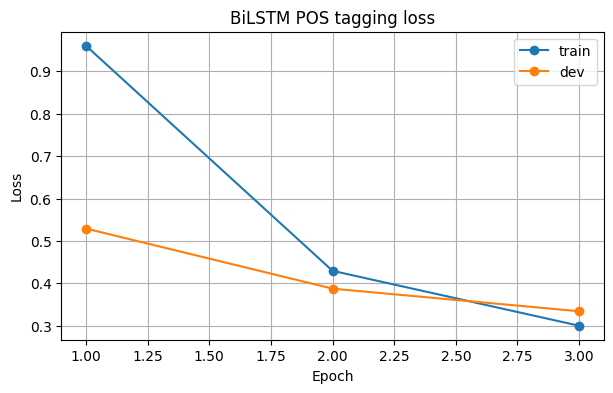

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(loss_table["epoch"], loss_table["train_loss"], marker="o", label="train")
plt.plot(loss_table["epoch"], loss_table["dev_loss"], marker="o", label="dev")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM POS tagging loss")
plt.legend()
plt.grid(True)
plt.show()

## Main results

Here I combine the required macro scores for the frequency baseline, the previous Window MLP, and the new RNN.

In [10]:
rnn_macro_rows = []
rnn_per_tag_rows = []

for split, loader in loaders.items():
    per_tag, macro = evaluate_rnn_model(rnn, loader)

    rnn_macro_rows.append({
        "model": "BiLSTM RNN",
        "split": split,
        **macro
    })

    temp = per_tag.copy()
    temp.insert(0, "split", split)
    temp.insert(0, "model", "BiLSTM RNN")
    rnn_per_tag_rows.append(temp)

rnn_macro = pd.DataFrame(rnn_macro_rows)
rnn_per_tag = pd.concat(rnn_per_tag_rows, ignore_index=True)

macro_results = pd.concat([freq_macro, old_window_mlp, rnn_macro], ignore_index=True)
macro_results = macro_results.sort_values(["split", "model"]).reset_index(drop=True)

display(macro_results)

,model,split,macro_precision,macro_recall,macro_f1,macro_pr_auc
0,BiLSTM RNN,dev,0.857587,0.796615,0.818982,0.857361
1,Most frequent tag,dev,0.836325,0.774837,0.791781,0.701176
2,Window MLP Part 3,dev,0.894500,0.833600,0.848600,0.888000
3,BiLSTM RNN,test,0.856187,0.807067,0.827772,0.870945
4,Most frequent tag,test,0.819922,0.775515,0.786675,0.702739
5,Window MLP Part 3,test,0.868900,0.846300,0.856300,0.898300
6,BiLSTM RNN,train,0.934931,0.876728,0.900176,0.939562
7,Most frequent tag,train,0.896462,0.872635,0.880112,0.798483
8,Window MLP Part 3,train,0.966300,0.911800,0.926000,0.960800


## Small hyperparameter check

I kept this extra check simple. It only compares the main dropout value with a smaller dropout value.
The selection is still based on the development set.

In [11]:
def train_small_dropout_variant(dropout_value, trial_epochs=2):
    trial = BiLstmPosTagger(
        vocab_size=len(word2idx),
        num_tags=len(tag_list),
        emb_dim=80,
        hidden_dim=128,
        num_layers=2,
        dropout=dropout_value
    ).to(device)

    trial_opt = torch.optim.Adam(trial.parameters(), lr=0.001)

    local_best = float("inf")
    local_weights = None

    for ep in range(1, trial_epochs + 1):
        tr = pass_over_data(trial, loaders["train"], trial_opt)
        dv = pass_over_data(trial, loaders["dev"], optimizer=None)

        if dv < local_best:
            local_best = dv
            local_weights = {k: v.detach().cpu().clone() for k, v in trial.state_dict().items()}

        print(f"dropout {dropout_value} | epoch {ep}: train={tr:.4f}, dev={dv:.4f}")

    trial.load_state_dict(local_weights)
    _, dev_macro = evaluate_rnn_model(trial, loaders["dev"])
    _, test_macro = evaluate_rnn_model(trial, loaders["test"])

    return {
        "setting": f"dropout={dropout_value}",
        "best_dev_loss": local_best,
        "dev_macro_f1": dev_macro["macro_f1"],
        "test_macro_f1": test_macro["macro_f1"],
        "dev_macro_pr_auc": dev_macro["macro_pr_auc"],
        "test_macro_pr_auc": test_macro["macro_pr_auc"],
    }


main_dev_row = rnn_macro[rnn_macro["split"] == "dev"].iloc[0]
main_test_row = rnn_macro[rnn_macro["split"] == "test"].iloc[0]

dropout_rows = [{
    "setting": "dropout=0.25 main model",
    "best_dev_loss": best_dev,
    "dev_macro_f1": main_dev_row["macro_f1"],
    "test_macro_f1": main_test_row["macro_f1"],
    "dev_macro_pr_auc": main_dev_row["macro_pr_auc"],
    "test_macro_pr_auc": main_test_row["macro_pr_auc"],
}]

dropout_rows.append(train_small_dropout_variant(0.10, trial_epochs=2))

dropout_summary = pd.DataFrame(dropout_rows).sort_values("dev_macro_f1", ascending=False)
display(dropout_summary)

dropout 0.1 | epoch 1: train=0.9252, dev=0.5018
dropout 0.1 | epoch 2: train=0.3820, dev=0.3646


,setting,best_dev_loss,dev_macro_f1,test_macro_f1,dev_macro_pr_auc,test_macro_pr_auc
0,dropout=0.25 main model,0.334225,0.818982,0.827772,0.857361,0.870945
1,dropout=0.1,0.364570,0.799198,0.810350,0.843929,0.859457


## Full per tag tables

Per tag results.
This cell creates one table with per-tag precision, recall, F1, and PR-AUC for the frequency baseline
and for the RNN, separately for train, development, and test. The old Window MLP macro scores are already
included above as the previous method baseline.

In [12]:
full_per_tag_results = pd.concat([freq_per_tag, rnn_per_tag], ignore_index=True)
full_per_tag_results = full_per_tag_results.sort_values(["model", "split", "tag"]).reset_index(drop=True)

macro_results.to_csv("exercise2_macro_results.csv", index=False)
full_per_tag_results.to_csv("exercise2_per_tag_results_frequency_and_rnn.csv", index=False)
dropout_summary.to_csv("exercise2_dropout_check.csv", index=False)

print("Saved:")
print("- exercise2_macro_results.csv")
print("- exercise2_per_tag_results_frequency_and_rnn.csv")
print("- exercise2_dropout_check.csv")

display(full_per_tag_results.head(20))

Saved:
- exercise2_macro_results.csv
- exercise2_per_tag_results_frequency_and_rnn.csv
- exercise2_dropout_check.csv


,model,split,tag,precision,recall,f1,pr_auc,support
0,BiLSTM RNN,dev,ADJ,0.842890,0.788204,0.814630,0.905212,1865
1,BiLSTM RNN,dev,ADP,0.923474,0.965162,0.943858,0.983529,2038
2,BiLSTM RNN,dev,ADV,0.913004,0.809253,0.858003,0.925284,1232
3,BiLSTM RNN,dev,AUX,0.978927,0.978302,0.978615,0.994217,1567
4,BiLSTM RNN,dev,CCONJ,0.992258,0.985897,0.989068,0.995881,780
5,BiLSTM RNN,dev,DET,0.979112,0.986842,0.982962,0.996618,1900
6,BiLSTM RNN,dev,INTJ,0.932432,0.600000,0.730159,0.733035,115
7,BiLSTM RNN,dev,NOUN,0.781471,0.893587,0.833777,0.918985,4210
8,BiLSTM RNN,dev,NUM,0.837838,0.728460,0.779330,0.820600,383
9,BiLSTM RNN,dev,PART,0.946809,0.962906,0.954789,0.990511,647


## Test tags that were easier and harder for the RNN

In [13]:
rnn_test_tags = full_per_tag_results[
    (full_per_tag_results["model"] == "BiLSTM RNN") &
    (full_per_tag_results["split"] == "test")
].copy()

best_tags = rnn_test_tags.sort_values("f1", ascending=False).head(8)
hard_tags = rnn_test_tags.sort_values("f1", ascending=True).head(8)

tag_summary_for_report = pd.concat([
    best_tags.assign(group="higher F1"),
    hard_tags.assign(group="lower F1")
])

display(tag_summary_for_report[["group", "tag", "precision", "recall", "f1", "pr_auc", "support"]])

,group,tag,precision,recall,f1,pr_auc,support
21,higher F1,CCONJ,0.995902,0.990489,0.993188,0.995310,736
29,higher F1,PUNCT,0.989631,0.986434,0.988030,0.998923,3096
22,higher F1,DET,0.984745,0.986821,0.985782,0.997475,1897
27,higher F1,PRON,0.979329,0.985213,0.982262,0.995069,2164
20,higher F1,AUX,0.983703,0.977965,0.980825,0.994636,1543
26,higher F1,PART,0.949924,0.964561,0.957187,0.986798,649
18,higher F1,ADP,0.929183,0.965432,0.946961,0.985487,2025
32,higher F1,VERB,0.881849,0.908253,0.894856,0.961967,2605
33,lower F1,X,0.000000,0.000000,0.000000,0.036554,42
28,lower F1,PROPN,0.705946,0.629398,0.665478,0.754185,2075


## Small random examples to understand how the model tags


In [14]:
def predict_tags_for_text(text):
    rnn.eval()

    words = text.lower().split()
    ids = [word2idx.get(word, unk_word_id) for word in words]

    x = torch.tensor([ids], dtype=torch.long).to(device)
    lengths = torch.tensor([len(ids)], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = rnn(x, lengths)
        pred_ids = logits.argmax(dim=-1).squeeze(0).cpu().numpy()

    return pd.DataFrame({
        "word": words,
        "predicted_tag": [idx2tag[int(i)] for i in pred_ids],
        "in_train_vocab": [w in word2idx for w in words]
    })


example_texts = [
    "Maria studies data science in Athens .",
    "The small model predicts tags for words .",
    "Alpha TV broadcast the show on Monday ."
]

for text in example_texts:
    print("\nSentence:", text)
    display(predict_tags_for_text(text))


Sentence: Maria studies data science in Athens .


,word,predicted_tag,in_train_vocab
0,maria,VERB,True
1,studies,PROPN,True
2,data,NOUN,True
3,science,NOUN,True
4,in,ADP,True
5,athens,NOUN,False
6,.,PUNCT,True



Sentence: The small model predicts tags for words .


,word,predicted_tag,in_train_vocab
0,the,DET,True
1,small,ADJ,True
2,model,NOUN,True
3,predicts,NOUN,False
4,tags,NOUN,False
5,for,ADP,True
6,words,NOUN,True
7,.,PUNCT,True



Sentence: Alpha TV broadcast the show on Monday .


,word,predicted_tag,in_train_vocab
0,alpha,PROPN,False
1,tv,NOUN,True
2,broadcast,VERB,False
3,the,DET,True
4,show,NOUN,True
5,on,ADP,True
6,monday,PROPN,True
7,.,PUNCT,True


## Final comments

The BiLSTM reads the full sentence and predicts one POS tag for every word.
In this run it clearly beats the simple most frequent tag baseline. The previous Window MLP from Part 3
is still a strong baseline, but the RNN is a more natural model for sequence labeling because it can use both
left and right context from the sentence.

The extra metric tables saved above are the ones that i use in the report when i mention that full per tag.
